In [ ]:
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt

# Find all CSV files in the current folder that start with "ob_report_"
files = glob("ob_report_*.csv")
# Print the list of files so we can check they were found
print(files)

# Read each CSV file into a pandas DataFrame and combine into one big table
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print("Total rows:", len(df)) #how many rows we have in total
df.head()

['ob_report_2018.csv', 'ob_report_2024.csv', 'ob_report_2025.csv', 'ob_report_2019.csv', 'ob_report_2021.csv', 'ob_report_2020.csv', 'ob_report_2022.csv', 'ob_report_2023.csv', 'ob_report_2017.csv', 'ob_report_2016.csv']
Total rows: 6553


,_id,Institution Name,Institution Address,Outbreak Setting,Type of Outbreak,Causative Agent-1,Causative Agent-2,Date Outbreak Began,Date Declared Over,Active,Causative Agent - 1,Causative Agent - 2
0,1,Eatonville Care Centre,420 The East Mall,LTCH,Respiratory,Influenza A (Not subtyped),NaN,2018-12-31,2019-01-25,N,NaN,NaN
1,2,Princess Margaret Hospital - 15B,610 Universtiy Ave,Hospital-Acute Care,Respiratory,Respiratory syncytial virus,NaN,2018-12-31,2019-01-08,N,NaN,NaN
2,3,Villa Colombo - 4th Fl Fusco,40 Playfair Ave,LTCH,Enteric,Unable to identify,NaN,2018-12-29,2019-01-12,N,NaN,NaN
3,4,Hellenic Home (Scarborough) - 2A & 3A,2411 Lawrence Ave E,LTCH,Enteric,Norovirus-like,NaN,2018-12-28,2019-01-16,N,NaN,NaN
4,5,Hillcrest Reactivation Centre - 2nd Fl,47 Austin Terr,Hospital-Chronic Care,Respiratory,Unable to identify,NaN,2018-12-28,2019-01-08,N,NaN,NaN


In [7]:
# Count how many outbreaks happened in each type of facility
counts = df["Outbreak Setting"].value_counts()
print(counts)

Outbreak Setting
LTCH                     3693
Retirement Home          1100
Hospital-Acute Care       870
Hospital-Chronic Care     755
Hospital-Psychiatric      106
Transitional Care          26
Shelter                     3
Name: count, dtype: int64


/var/folders/ps/9mfd94h1197dqk96m56rhv040000gn/T/ipykernel_99347/2539659526.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45, ha="right") #rotate labels so no overlap


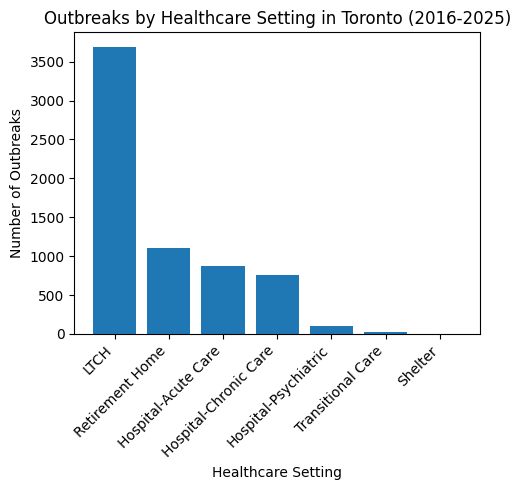

In [11]:

# Create a figure
fig, ax = plt.subplots(figsize=(5, 5))

# Plot counts as a bar chart
ax.bar(counts.index, counts.values)
ax.set_ylabel("Number of Outbreaks") #label y-axis
ax.set_xlabel("Healthcare Setting") #label x-axis
ax.set_title("Outbreaks by Healthcare Setting in Toronto (2016-2025)") #add a title
ax.set_xticklabels(counts.index, rotation=45, ha="right") #rotate labels so no overlap
plt.tight_layout()

plt.show()

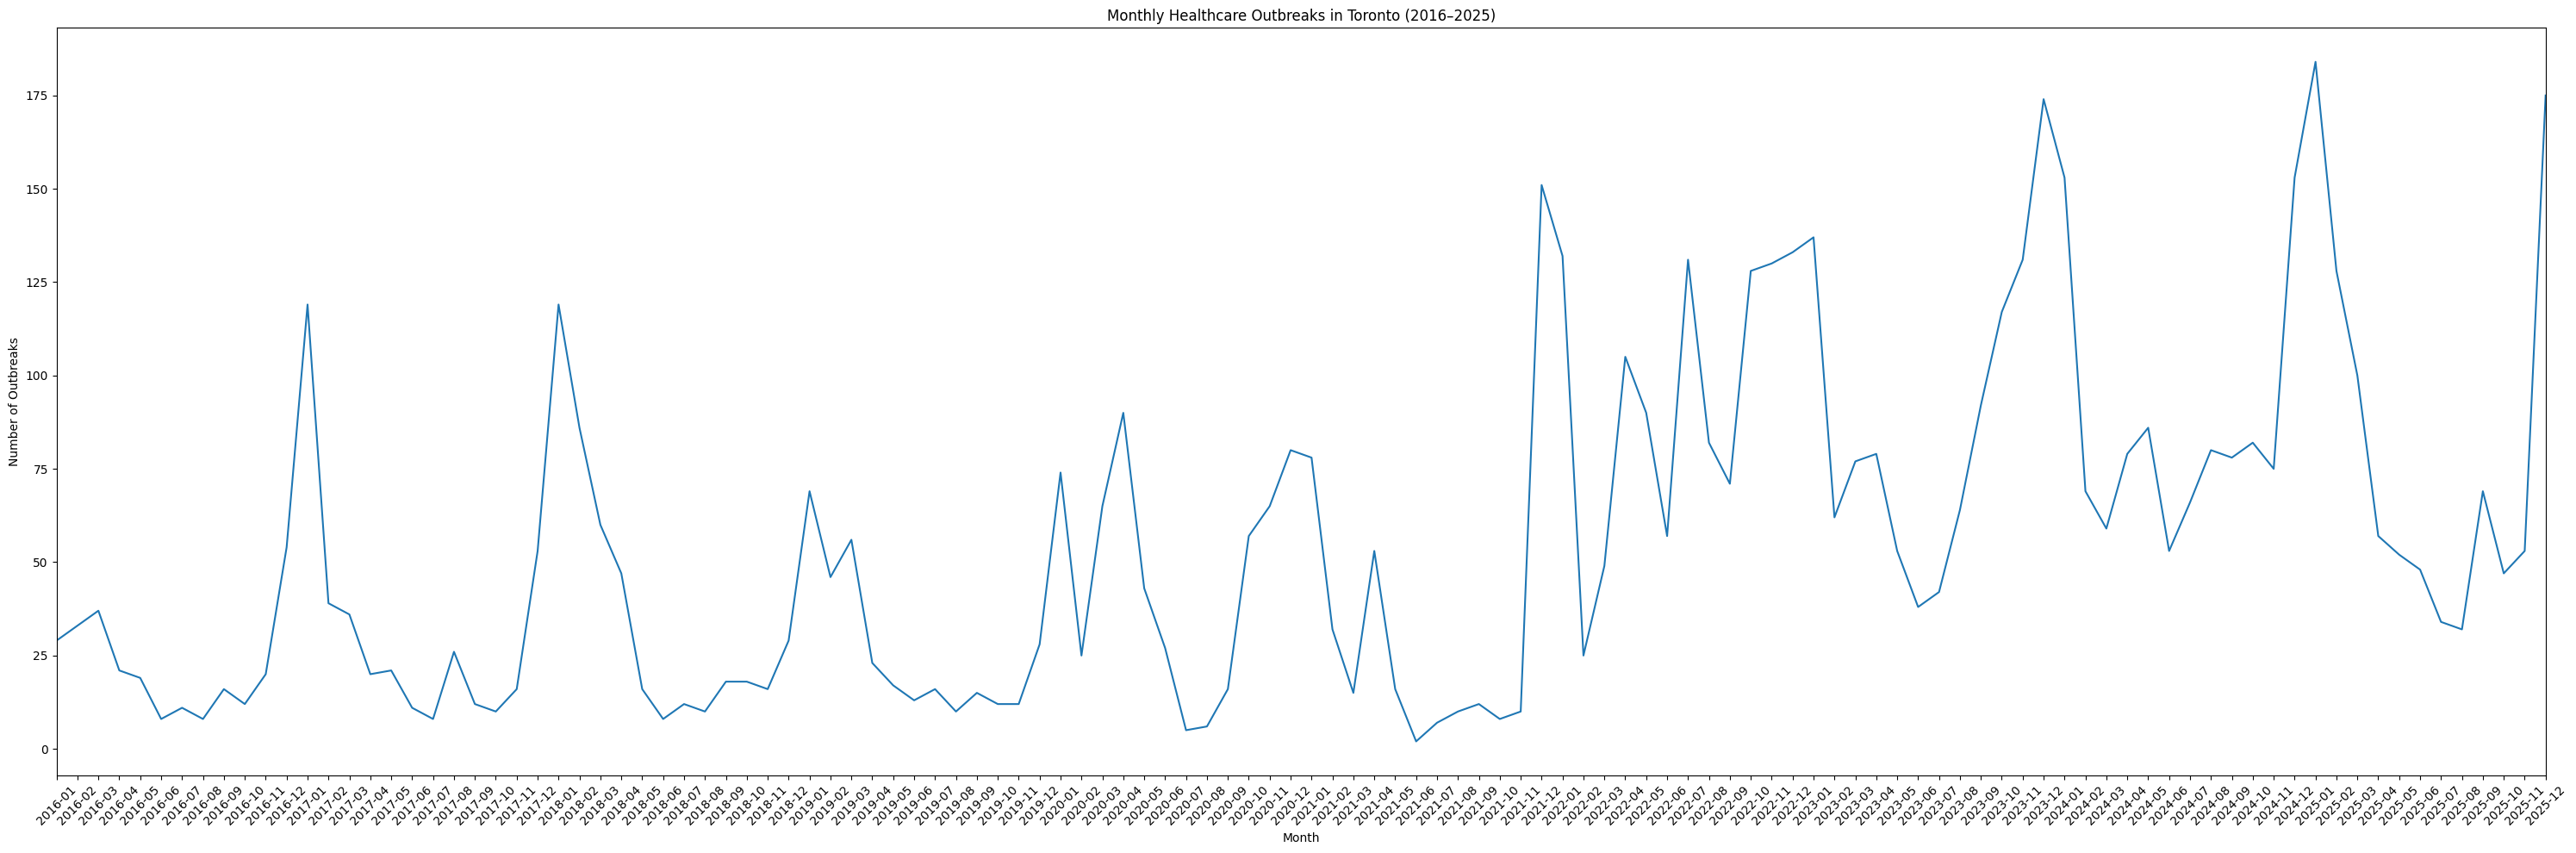

In [ ]:
# Convert the data outbreak began column to datetime format
df["Date Outbreak Began"] = pd.to_datetime(df["Date Outbreak Began"])

# Create a new column that stores the year-month (e.g. 2020-03)
df["month"] = df["Date Outbreak Began"].dt.to_period("M")

# Count how many outbreaks happened each month
monthly = df.groupby("month").size()

# Create a new figure and axis
fig, ax = plt.subplots(figsize=(30, 10))
ax.plot(monthly.index.astype(str), monthly.values)
ax.set_ylabel("Number of Outbreaks")
ax.set_xlabel("Month")
ax.set_title("Monthly Healthcare Outbreaks in Toronto (2016–2025)")
ax.tick_params(axis="x", rotation=45)
ax.margins(x=0) #remove x-axis blank margins
plt.tight_layout()

plt.show()